# Ward 1 Pothole — EDA and Feature Preparation (2023)

**Goal:** Build a fully engineered daily feature matrix (Ward 1 pothole counts × weather × calendar features) ready for Poisson GLM fitting in a follow-up notebook.

**Pipeline:**
1. Load 2023 service requests → Ward 1 pothole daily counts + centroid coordinates
2. Fetch hourly Open-Meteo weather for the Ward 1 centroid → aggregate to daily
3. EDA: time series, day-of-week, seasonality, correlations
4. Feature engineering: weather flags, freeze-thaw cycles, Fourier seasonality, DOW dummies, lag features
5. Assemble and inspect final `model_df`

## Step 1 — Load and filter 2023 service requests

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import date

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [36]:
df = pd.read_csv("All_Service_Requests_-_2023.csv")
df["ADDDATE"] = pd.to_datetime(df["ADDDATE"], errors="coerce")
df["date"] = df["ADDDATE"].dt.date

print(f"Total rows: {len(df):,}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.head(2)

Total rows: 425,243
Date range: 2023-01-01 → 2024-01-01


,X,Y,SERVICEREQUESTID,STREETADDRESS,CITY,STATE,ZIPCODE,WARD,SERVICECODE,SERVICECODEDESCRIPTION,SERVICETYPECODEDESCRIPTION,ORGANIZATIONACRONYM,SERVICECALLCOUNT,ADDDATE,RESOLUTIONDATE,SERVICEDUEDATE,SERVICEORDERDATE,INSPECTIONFLAG,INSPECTIONDATE,INSPECTORNAME,SERVICEORDERSTATUS,STATUS_CODE,DETAILS,PRIORITY,XCOORD,YCOORD,LATITUDE,LONGITUDE,MARADDRESSREPOSITORYID,GLOBALID,CREATED,EDITED,SE_ANNO_CAD_DATA,OBJECTID,date
0,398389.57,138810.81,23-00000008,2019 5TH STREET NW,WASHINGTON,DC,20001.0,Ward 1,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2023-01-01 05:54:29+00:00,2023/01/01 11:36:13+00,2023/01/03 05:54:28+00,2023/01/01 05:54:29+00,NaN,NaN,NaN,Closed,NaN,NaN,Standard,398389.57,138810.81,38.917164,-77.018570,229609,{F12E953E-26CA-1E18-E053-782F520AC63D},NaN,NaN,NaN,10579627,2023-01-01
1,399970.25,134587.11,23-00000013,401 I STREET SE,WASHINGTON,DC,20003.0,Ward 6,S0261,Parking Enforcement,PEMA- Parking Enforcement Management Administr...,DPW,1,2023-01-01 06:28:39+00:00,2023/01/01 11:36:53+00,2023/01/03 06:28:38+00,2023/01/01 06:28:39+00,NaN,NaN,NaN,Closed,NaN,NaN,Standard,399970.25,134587.11,38.879117,-77.000343,288070,{F12F0091-4F4F-7AFF-E053-782F520A8FBD},NaN,NaN,NaN,10579628,2023-01-01


In [37]:
# Compute Ward 1 centroid from all service types (not just potholes)
ward1_all = df[df["WARD"] == "Ward 1"].dropna(subset=["LATITUDE", "LONGITUDE"])
ward1_lat = ward1_all["LATITUDE"].mean()
ward1_lon = ward1_all["LONGITUDE"].mean()
print(f"Ward 1 centroid: {ward1_lat:.5f} °N, {ward1_lon:.5f} °E")

Ward 1 centroid: 38.92633 °N, -77.03091 °E


In [38]:
# Filter to Ward 1 pothole requests
pothole_mask = (
    (df["WARD"] == "Ward 1") &
    (df["SERVICECODEDESCRIPTION"] == 'Pothole')
)
df_potholes = df.loc[pothole_mask].copy()
print(f"Ward 1 pothole requests: {len(df_potholes):,}")
print(df_potholes["SERVICECODEDESCRIPTION"].value_counts())

Ward 1 pothole requests: 220
SERVICECODEDESCRIPTION
Pothole    220
Name: count, dtype: int64


In [39]:
# Build daily count series, filling days with zero requests
raw_counts = (
    df_potholes.groupby("date")
    .size()
    .rename("pothole_count")
    .reset_index()
)
raw_counts["date"] = pd.to_datetime(raw_counts["date"]).dt.date

full_calendar = pd.DataFrame(
    {"date": [d.date() for d in pd.date_range("2023-01-01", "2023-12-31", freq="D")]}
)
daily_counts = full_calendar.merge(raw_counts, on="date", how="left").fillna(0)
daily_counts["pothole_count"] = daily_counts["pothole_count"].astype(int)

print(f"Days in series: {len(daily_counts)}")
print(f"Days with zero requests: {(daily_counts['pothole_count'] == 0).sum()}")
print(f"Total requests: {daily_counts['pothole_count'].sum():,}")
daily_counts.head()

Days in series: 365
Days with zero requests: 219
Total requests: 220


,date,pothole_count
0,2023-01-01,0
1,2023-01-02,0
2,2023-01-03,2
3,2023-01-04,3
4,2023-01-05,3


## Step 2 — Fetch and aggregate Open-Meteo hourly weather

Weather data is fetched once and cached locally as a Parquet file in `weather_cache/`.  
The query parameters are stored separately in `configs/weather_ward1_2023.json` (version-controlled).  
On subsequent runs `load_or_fetch()` loads from disk without hitting the API.

In [40]:
import json
from weather_fetch import get_hourly_weather, aggregate_to_daily, load_or_fetch

# Load query config from configs/ (version-controlled, no coordinates)
with open("configs/weather_ward1_2023.json") as f:
    WEATHER_CONFIG = json.load(f)

print("Query config:")
for k, v in WEATHER_CONFIG.items():
    print(f"  {k}: {v}")

Query config:
  label: weather_ward1_2023
  ward: Ward 1
  description: Hourly weather for the Ward 1 service-request centroid, 2023 analysis window. start_date is 2022-12-01 (31-day buffer) so the full 30-day freeze-thaw cycle lookback window is available for every day in January 2023.
  api_url: https://archive-api.open-meteo.com/v1/archive
  start_date: 2022-12-01
  end_date: 2023-12-31
  variables: ['temperature_2m', 'precipitation', 'snowfall']
  timezone: America/New_York
  latitude_source: mean LATITUDE of all Ward 1 service requests in All_Service_Requests_-_2023.csv
  longitude_source: mean LONGITUDE of all Ward 1 service requests in All_Service_Requests_-_2023.csv
  notes: latitude and longitude are computed at runtime and recorded in weather_cache/<label>_metadata.json alongside the parquet file.


In [41]:
# Load from cache if available, otherwise fetch from API and save.
# ward1_lat / ward1_lon were computed in Step 1 from the service-request data.
df_hourly, weather_meta = load_or_fetch(
    config=WEATHER_CONFIG,
    lat=ward1_lat,
    lon=ward1_lon,
    cache_dir="weather_cache",
)

print(f"\nHourly rows: {len(df_hourly):,}")
print(f"Date range:  {df_hourly['date'].min()} → {df_hourly['date'].max()}")
df_hourly.head()

No cache found — fetching from Open-Meteo API ...
Saved  weather_cache/weather_ward1_2023.parquet  (9,504 rows)
Saved  weather_cache/weather_ward1_2023_metadata.json

Hourly rows: 9,504
Date range:  2022-12-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00


,date,temperature_2m,precipitation,snowfall
0,2022-12-01 00:00:00+00:00,4.25,0.0,0.0
1,2022-12-01 01:00:00+00:00,3.15,0.0,0.0
2,2022-12-01 02:00:00+00:00,2.15,0.0,0.0
3,2022-12-01 03:00:00+00:00,1.55,0.0,0.0
4,2022-12-01 04:00:00+00:00,1.10,0.0,0.0


In [42]:
df_weather = aggregate_to_daily(df_hourly)

# Keep only 2023 rows for the model.
# The 2022-12-31 buffer row is used implicitly by the FTC and lag cells
# which operate directly on df_hourly.
df_weather_2023 = df_weather[df_weather["date"] >= date(2023, 1, 1)].reset_index(drop=True)

print(f"Daily weather rows (2023): {len(df_weather_2023)}")
print(f"\nAs-executed metadata:")
for k, v in weather_meta.items():
    print(f"  {k}: {v}")
df_weather_2023.head()

Daily weather rows (2023): 365

As-executed metadata:
  label: weather_ward1_2023
  ward: Ward 1
  description: Hourly weather for the Ward 1 service-request centroid, 2023 analysis window. start_date is 2022-12-01 (31-day buffer) so the full 30-day freeze-thaw cycle lookback window is available for every day in January 2023.
  api_url: https://archive-api.open-meteo.com/v1/archive
  start_date: 2022-12-01
  end_date: 2023-12-31
  variables: ['temperature_2m', 'precipitation', 'snowfall']
  timezone: America/New_York
  latitude_source: mean LATITUDE of all Ward 1 service requests in All_Service_Requests_-_2023.csv
  longitude_source: mean LONGITUDE of all Ward 1 service requests in All_Service_Requests_-_2023.csv
  notes: latitude and longitude are computed at runtime and recorded in weather_cache/<label>_metadata.json alongside the parquet file.
  latitude: 38.926330366779794
  longitude: -77.03090593701488


,date,tmax_c,tmin_c,tmean_c,precip_mm,snow_cm
0,2023-01-01,15.850000,6.80,10.856250,0.0,0.0
1,2023-01-02,17.299999,5.75,10.839583,0.0,0.0
2,2023-01-03,18.400000,10.25,14.541667,0.0,0.0
3,2023-01-04,17.299999,10.65,14.941667,6.2,0.0
4,2023-01-05,15.300000,8.35,12.252083,0.8,0.0


## Step 3 — Merge and initial EDA

In [43]:
# Merge pothole counts with daily weather on date
merged = daily_counts.merge(df_weather_2023, on="date", how="left")
merged["date_dt"] = pd.to_datetime(merged["date"])
merged["day_of_year"] = merged["date_dt"].dt.day_of_year
merged["day_of_week"] = merged["date_dt"].dt.dayofweek   # 0=Mon, 6=Sun

print(f"Merged shape: {merged.shape}")
print(f"Nulls:\n{merged.isnull().sum()}")
merged.head()

Merged shape: (365, 10)
Nulls:
date             0
pothole_count    0
tmax_c           0
tmin_c           0
tmean_c          0
precip_mm        0
snow_cm          0
date_dt          0
day_of_year      0
day_of_week      0
dtype: int64


,date,pothole_count,tmax_c,tmin_c,tmean_c,precip_mm,snow_cm,date_dt,day_of_year,day_of_week
0,2023-01-01,0,15.850000,6.80,10.856250,0.0,0.0,2023-01-01,1,6
1,2023-01-02,0,17.299999,5.75,10.839583,0.0,0.0,2023-01-02,2,0
2,2023-01-03,2,18.400000,10.25,14.541667,0.0,0.0,2023-01-03,3,1
3,2023-01-04,3,17.299999,10.65,14.941667,6.2,0.0,2023-01-04,4,2
4,2023-01-05,3,15.300000,8.35,12.252083,0.8,0.0,2023-01-05,5,3


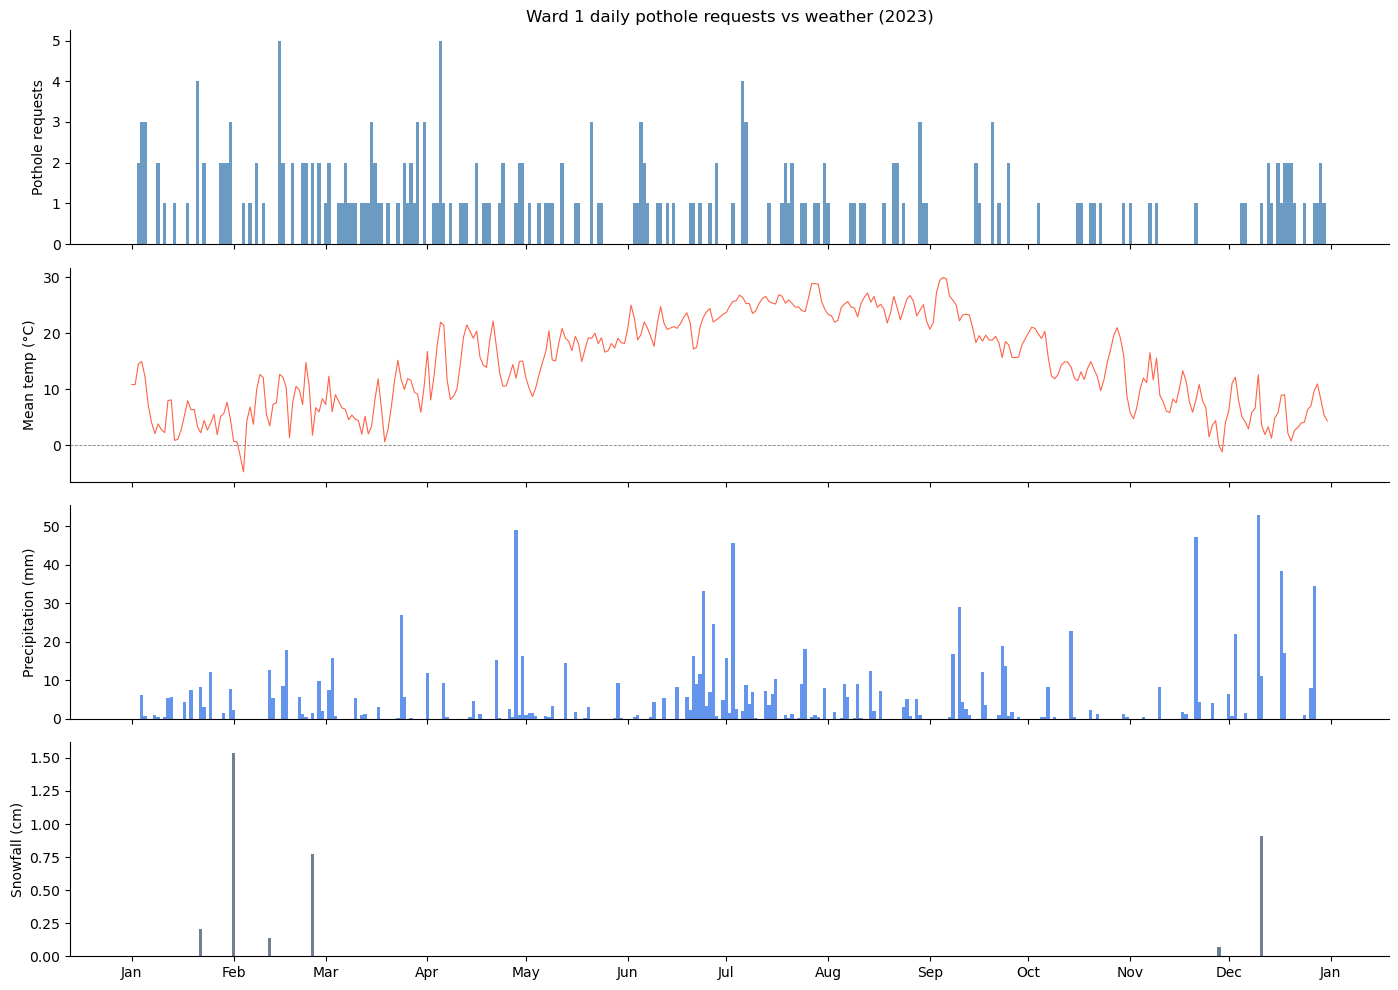

In [44]:
# --- Time series: pothole counts overlaid with weather variables ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].bar(merged["date_dt"], merged["pothole_count"], color="steelblue", width=1, alpha=0.8)
axes[0].set_ylabel("Pothole requests")
axes[0].set_title("Ward 1 daily pothole requests vs weather (2023)")

axes[1].plot(merged["date_dt"], merged["tmean_c"], color="tomato", linewidth=0.8)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.6)
axes[1].set_ylabel("Mean temp (°C)")

axes[2].bar(merged["date_dt"], merged["precip_mm"], color="cornflowerblue", width=1)
axes[2].set_ylabel("Precipitation (mm)")

axes[3].bar(merged["date_dt"], merged["snow_cm"], color="slategray", width=1)
axes[3].set_ylabel("Snowfall (cm)")
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[3].xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

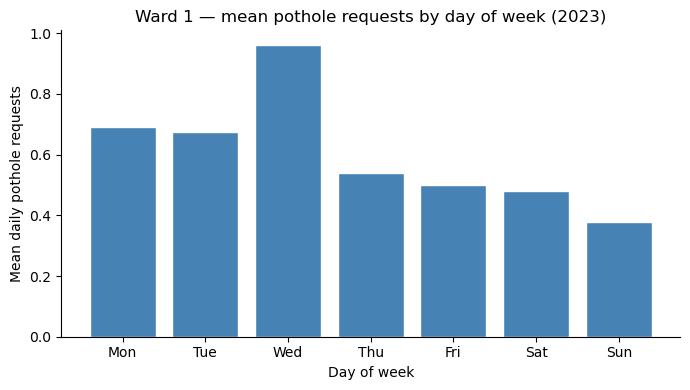

day_of_week
Mon    0.692308
Tue    0.673077
Wed    0.961538
Thu    0.538462
Fri    0.500000
Sat    0.480769
Sun    0.377358
Name: pothole_count, dtype: float64


In [45]:
# --- Day-of-week bar chart ---
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_means = merged.groupby("day_of_week")["pothole_count"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dow_labels, dow_means.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Day of week")
ax.set_ylabel("Mean daily pothole requests")
ax.set_title("Ward 1 — mean pothole requests by day of week (2023)")
plt.tight_layout()
plt.show()

print(dow_means.rename(index=dict(enumerate(dow_labels))))

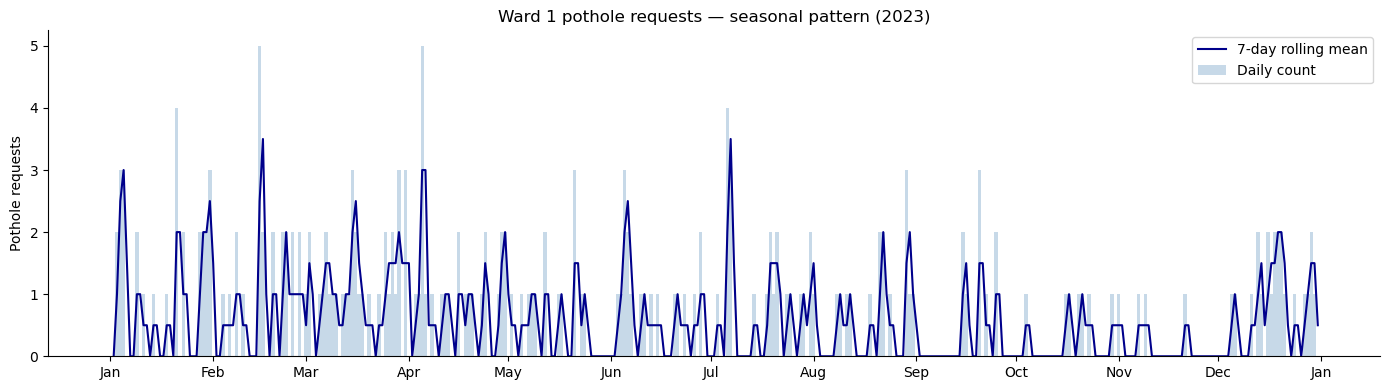

In [47]:
# --- Seasonal pattern: 7-day rolling mean ---
rolling_mean = merged.set_index("date_dt")["pothole_count"].rolling(2, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(merged["date_dt"], merged["pothole_count"], color="steelblue", width=1, alpha=0.3, label="Daily count")
ax.plot(rolling_mean.index, rolling_mean.values, color="darkblue", linewidth=1.5, label="7-day rolling mean")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Pothole requests")
ax.set_title("Ward 1 pothole requests — seasonal pattern (2023)")
ax.legend()
plt.tight_layout()
plt.show()

Mean:     0.603
Variance: 0.806
Variance / Mean (dispersion index): 1.337  — >1 suggests overdispersion


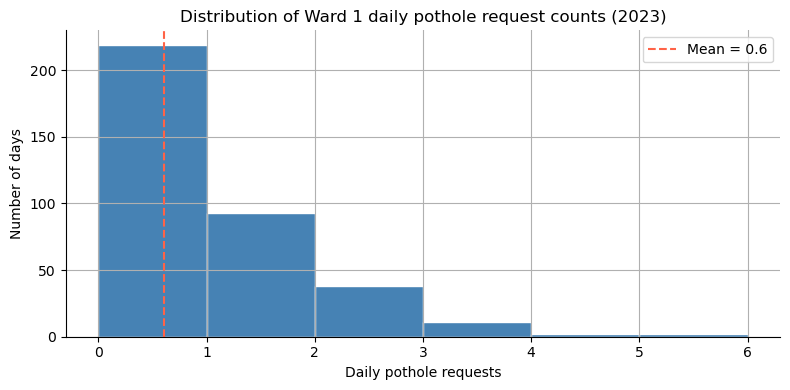

In [48]:
# --- Distribution of daily pothole counts (mean vs variance check) ---
mu = merged["pothole_count"].mean()
var = merged["pothole_count"].var()
print(f"Mean:     {mu:.3f}")
print(f"Variance: {var:.3f}")
print(f"Variance / Mean (dispersion index): {var/mu:.3f}  — >1 suggests overdispersion")

fig, ax = plt.subplots(figsize=(8, 4))
merged["pothole_count"].hist(bins=range(0, merged["pothole_count"].max() + 2), ax=ax,
                              color="steelblue", edgecolor="white")
ax.axvline(mu, color="tomato", linestyle="--", label=f"Mean = {mu:.1f}")
ax.set_xlabel("Daily pothole requests")
ax.set_ylabel("Number of days")
ax.set_title("Distribution of Ward 1 daily pothole request counts (2023)")
ax.legend()
plt.tight_layout()
plt.show()

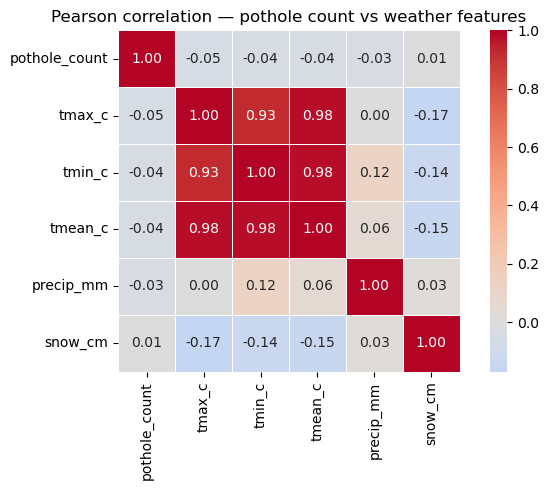

In [49]:
# --- Correlation heatmap: pothole count vs continuous weather features ---
corr_cols = ["pothole_count", "tmax_c", "tmin_c", "tmean_c", "precip_mm", "snow_cm"]
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson correlation — pothole count vs weather features")
plt.tight_layout()
plt.show()

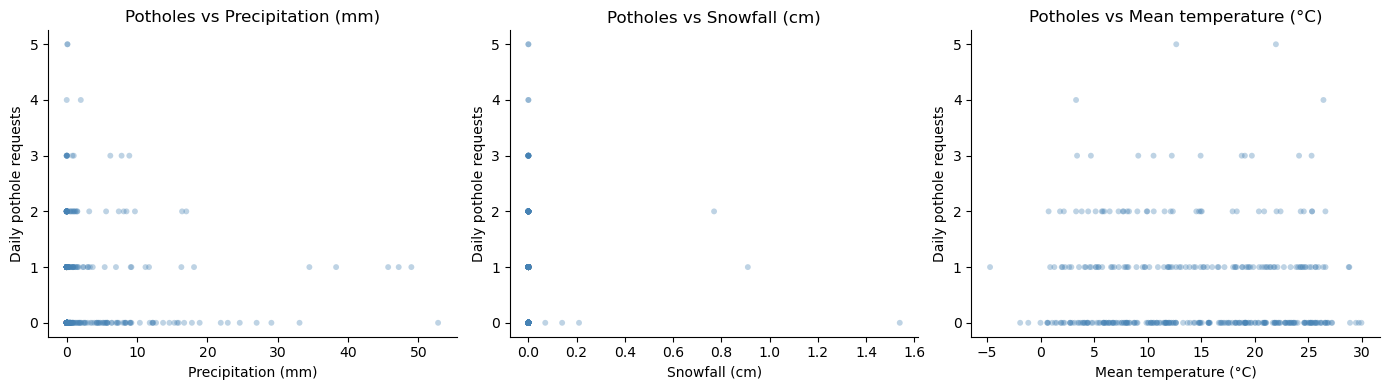

In [50]:
# --- Scatter plots: pothole count vs individual weather features ---
scatter_vars = [
    ("precip_mm", "Precipitation (mm)"),
    ("snow_cm", "Snowfall (cm)"),
    ("tmean_c", "Mean temperature (°C)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label) in zip(axes, scatter_vars):
    ax.scatter(merged[col], merged["pothole_count"],
               alpha=0.35, s=18, color="steelblue", edgecolors="none")
    ax.set_xlabel(label)
    ax.set_ylabel("Daily pothole requests")
    ax.set_title(f"Potholes vs {label}")
plt.tight_layout()
plt.show()

## Step 4 — Feature engineering

In [51]:
# --- Weather-derived daily flags ---
feats = merged.copy()

feats["t_range"]        = feats["tmax_c"] - feats["tmin_c"]
feats["freeze_day"]     = (feats["tmin_c"] < 0).astype(int)
feats["freeze_thaw_day"]= ((feats["tmin_c"] < 0) & (feats["tmax_c"] > 0)).astype(int)
feats["heavy_rain_day"] = (feats["precip_mm"] >= 10).astype(int)

print("Weather flags added:")
print(feats[["date", "tmax_c", "tmin_c", "t_range", "freeze_day",
             "freeze_thaw_day", "heavy_rain_day"]].head(10))

Weather flags added:
         date     tmax_c  tmin_c    t_range  freeze_day  freeze_thaw_day  \
0  2023-01-01  15.850000    6.80   9.050000           0                0   
1  2023-01-02  17.299999    5.75  11.549999           0                0   
2  2023-01-03  18.400000   10.25   8.150000           0                0   
3  2023-01-04  17.299999   10.65   6.650000           0                0   
4  2023-01-05  15.300000    8.35   6.950000           0                0   
5  2023-01-06   9.750000    3.90   5.850000           0                0   
6  2023-01-07   8.350000    0.60   7.750000           0                0   
7  2023-01-08   5.850000   -2.00   7.850000           1                1   
8  2023-01-09   7.900000    1.15   6.750000           0                0   
9  2023-01-10   8.450000   -2.00  10.450000           1                1   

   heavy_rain_day  
0               0  
1               0  
2               0  
3               0  
4               0  
5               0  
6 

In [52]:
# --- Freeze-thaw cycle count from hourly series ---
# A cycle = qualifying freeze (< 0°C for >= 4 consecutive hours)
#            followed by qualifying thaw (> 4°C for >= 4 consecutive hours)

def count_freeze_thaw_cycles(hourly_series: pd.Series, min_hours: int = 4,
                              thaw_thresh: float = 4.0) -> int:
    """
    Count qualifying freeze-thaw cycles in an hourly temperature series.
    Uses run-length encoding: labels each hour F/T/N, filters qualifying
    runs (length >= min_hours), then counts adjacent F→T pairs.
    """
    temps = hourly_series.values

    # Label each hour
    labels = np.where(temps < 0, "F", np.where(temps > thaw_thresh, "T", "N"))

    # Run-length encode
    runs = []
    current, count = labels[0], 1
    for lbl in labels[1:]:
        if lbl == current:
            count += 1
        else:
            runs.append((current, count))
            current, count = lbl, 1
    runs.append((current, count))

    # Keep only qualifying F and T runs
    qualifying = [(lbl, n) for lbl, n in runs if lbl in ("F", "T") and n >= min_hours]

    # Count adjacent F→T pairs
    cycles = sum(
        1 for i in range(len(qualifying) - 1)
        if qualifying[i][0] == "F" and qualifying[i + 1][0] == "T"
    )
    return cycles


# For each day in 2023, count qualifying freeze-thaw cycles in the
# preceding 30-day hourly window.  The fetch window starts 2022-12-01,
# so every January date has a full 30-day lookback available.
FTC_LOOKBACK_DAYS = 30

ftc_records = []
for target_date in [d.date() for d in pd.date_range("2023-01-01", "2023-12-31")]:
    # tz-aware timestamps to match the UTC-aware date column from the API
    window_start = pd.Timestamp(target_date, tz="UTC") - pd.Timedelta(days=FTC_LOOKBACK_DAYS)
    window_end   = pd.Timestamp(target_date, tz="UTC")   # up to but not including target day
    mask = (df_hourly["date"] >= window_start) & (df_hourly["date"] < window_end)
    window = df_hourly.loc[mask, "temperature_2m"]
    ftc_records.append({
        "date":    target_date,
        "ftc_30d": count_freeze_thaw_cycles(window),
    })

ftc_df = pd.DataFrame(ftc_records)
feats = feats.merge(ftc_df, on="date", how="left")

print(f"30-day FTC feature added — days with ftc_30d > 0: {(feats['ftc_30d'] > 0).sum()}")
print(feats[feats["ftc_30d"] > 0][["date", "tmin_c", "tmax_c", "ftc_30d"]].head(10))

30-day FTC feature added — days with ftc_30d > 0: 146
         date  tmin_c     tmax_c  ftc_30d
0  2023-01-01    6.80  15.850000       10
1  2023-01-02    5.75  17.299999        9
2  2023-01-03   10.25  18.400000        9
3  2023-01-04   10.65  17.299999        9
4  2023-01-05    8.35  15.300000        9
5  2023-01-06    3.90   9.750000        9
6  2023-01-07    0.60   8.350000        9
7  2023-01-08   -2.00   5.850000        9
8  2023-01-09    1.15   7.900000       10
9  2023-01-10   -2.00   8.450000        9


In [53]:
# --- Temporal / calendar features ---
feats["is_weekend"] = (feats["day_of_week"] >= 5).astype(int)

# Fourier encoding of day-of-year (smooth, wrap-around seasonal signal)
feats["sin_doy"] = np.sin(2 * np.pi * feats["day_of_year"] / 365)
feats["cos_doy"] = np.cos(2 * np.pi * feats["day_of_year"] / 365)

# Day-of-week dummies (Sun = reference, drop to avoid collinearity)
dow_dummies = pd.get_dummies(feats["day_of_week"], prefix="dow", drop_first=False)
dow_dummies.columns = [f"dow_{c}" for c in ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]]
dow_dummies = dow_dummies.drop(columns=["dow_Sun"])  # Sunday = reference level
feats = pd.concat([feats, dow_dummies], axis=1)

print("Calendar features added — DOW dummies:")
print(feats[["date", "day_of_week", "is_weekend", "sin_doy", "cos_doy"] +
            list(dow_dummies.columns)].head(10))

Calendar features added — DOW dummies:
         date  day_of_week  is_weekend   sin_doy   cos_doy  dow_Mon  dow_Tue  \
0  2023-01-01            6           1  0.017213  0.999852    False    False   
1  2023-01-02            0           0  0.034422  0.999407     True    False   
2  2023-01-03            1           0  0.051620  0.998667    False     True   
3  2023-01-04            2           0  0.068802  0.997630    False    False   
4  2023-01-05            3           0  0.085965  0.996298    False    False   
5  2023-01-06            4           0  0.103102  0.994671    False    False   
6  2023-01-07            5           1  0.120208  0.992749    False    False   
7  2023-01-08            6           1  0.137279  0.990532    False    False   
8  2023-01-09            0           0  0.154309  0.988023     True    False   
9  2023-01-10            1           0  0.171293  0.985220    False     True   

   dow_Wed  dow_Thu  dow_Fri  dow_Sat  
0    False    False    False    False  


In [54]:
# --- Lag features ---
feats = feats.sort_values("date").reset_index(drop=True)
feats["pothole_lag1"] = feats["pothole_count"].shift(1)
feats["pothole_lag7"] = feats["pothole_count"].shift(7)

print("Lag features (first 10 rows):")
print(feats[["date", "pothole_count", "pothole_lag1", "pothole_lag7"]].head(10))

Lag features (first 10 rows):
         date  pothole_count  pothole_lag1  pothole_lag7
0  2023-01-01              0           NaN           NaN
1  2023-01-02              0           0.0           NaN
2  2023-01-03              2           0.0           NaN
3  2023-01-04              3           2.0           NaN
4  2023-01-05              3           3.0           NaN
5  2023-01-06              0           3.0           NaN
6  2023-01-07              0           0.0           NaN
7  2023-01-08              0           0.0           0.0
8  2023-01-09              2           0.0           0.0
9  2023-01-10              0           2.0           2.0


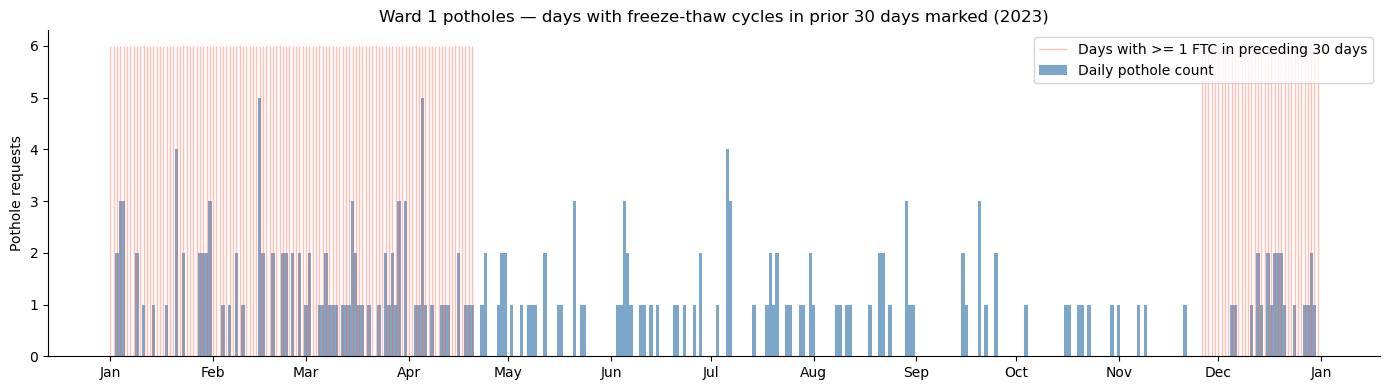

In [55]:
# --- Visualise freeze-thaw events on the time series ---
ftc_days = feats[feats["ftc_30d"] > 0]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(feats["date_dt"], feats["pothole_count"], color="steelblue", width=1, alpha=0.7,
       label="Daily pothole count")
ax.vlines(pd.to_datetime(ftc_days["date"]), 0, feats["pothole_count"].max() + 1,
          color="tomato", alpha=0.4, linewidth=1.0,
          label="Days with >= 1 FTC in preceding 30 days")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylabel("Pothole requests")
ax.set_title("Ward 1 potholes — days with freeze-thaw cycles in prior 30 days marked (2023)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Assemble final feature matrix

In [56]:
MODEL_FEATURES = [
    # target
    "pothole_count",
    # weather (raw)
    "tmax_c", "tmin_c", "tmean_c", "precip_mm", "snow_cm",
    # weather (engineered)
    "t_range", "freeze_day", "freeze_thaw_day", "heavy_rain_day",
    # freeze-thaw cycles — 30-day rolling lookback
    "ftc_30d",
    # calendar
    "day_of_year", "sin_doy", "cos_doy", "is_weekend",
    # DOW dummies (Sun = reference, omitted)
    "dow_Mon", "dow_Tue", "dow_Wed", "dow_Thu", "dow_Fri", "dow_Sat",
    # lags
    "pothole_lag1", "pothole_lag7",
]

model_df = feats[["date"] + MODEL_FEATURES].copy()

# Drop the first 7 rows where lag features are NaN
model_df = model_df.dropna().reset_index(drop=True)

print(f"model_df shape: {model_df.shape}")
print(f"Date range: {model_df['date'].min()} → {model_df['date'].max()}")
model_df.info()

model_df shape: (358, 24)
Date range: 2023-01-08 → 2023-12-31
<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             358 non-null    object 
 1   pothole_count    358 non-null    int64  
 2   tmax_c           358 non-null    float32
 3   tmin_c           358 non-null    float32
 4   tmean_c          358 non-null    float32
 5   precip_mm        358 non-null    float32
 6   snow_cm          358 non-null    float32
 7   t_range          358 non-null    float32
 8   freeze_day       358 non-null    int64  
 9   freeze_thaw_day  358 non-null    int64  
 10  heavy_rain_day   358 non-null    int64  
 11  ftc_30d          358 non-null    int64  
 12  day_of_year      358 non-null    int32  
 13  sin_doy          358 non-null    float64
 14  cos_doy          358 non-null    float64
 15  is_weekend       358 non-null    int64  
 16  dow_Mon    

In [ ]:
model_df.describe().round(3)

In [57]:
# --- Variance Inflation Factor check for continuous features ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

continuous_features = [
    "tmax_c", "tmin_c", "tmean_c", "precip_mm", "snow_cm",
    "t_range", "ftc_30d",
    "day_of_year", "sin_doy", "cos_doy",
    "pothole_lag1", "pothole_lag7",
]

X_vif = model_df[continuous_features].astype(float).values
vif_data = pd.DataFrame({
    "feature": continuous_features,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factors (continuous features):")
print(vif_data.to_string(index=False))
print()
high_vif = vif_data[vif_data["VIF"] > 10]
if len(high_vif):
    print(f"WARNING: {len(high_vif)} feature(s) with VIF > 10 — consider dropping or combining:")
    print(high_vif.to_string(index=False))
else:
    print("All VIFs <= 10 — no severe multicollinearity detected.")

Variance Inflation Factors (continuous features):
     feature          VIF
      tmax_c 9.007199e+15
      tmin_c 3.002400e+15
     t_range 3.002400e+15
     tmean_c 8.568506e+02
 day_of_year 9.989178e+00
     cos_doy 8.888303e+00
     ftc_30d 5.192388e+00
     sin_doy 3.507435e+00
pothole_lag7 1.654960e+00
pothole_lag1 1.615924e+00
   precip_mm 1.375065e+00
     snow_cm 1.042823e+00

feature          VIF
 tmax_c 9.007199e+15
 tmin_c 3.002400e+15
t_range 3.002400e+15
tmean_c 8.568506e+02


In [58]:
print("=== Final model_df ready for GLM fitting ===")
print(f"  Rows:     {len(model_df)}")
print(f"  Features: {len(MODEL_FEATURES) - 1}  (excl. target)")
print(f"  Target:   pothole_count  (mean={model_df['pothole_count'].mean():.2f}, "
      f"var={model_df['pothole_count'].var():.2f})")
model_df.head()

=== Final model_df ready for GLM fitting ===
  Rows:     358
  Features: 22  (excl. target)
  Target:   pothole_count  (mean=0.59, var=0.78)


,date,pothole_count,tmax_c,tmin_c,tmean_c,precip_mm,snow_cm,t_range,freeze_day,freeze_thaw_day,heavy_rain_day,ftc_30d,day_of_year,sin_doy,cos_doy,is_weekend,dow_Mon,dow_Tue,dow_Wed,dow_Thu,dow_Fri,dow_Sat,pothole_lag1,pothole_lag7
0,2023-01-08,0,5.85,-2.00,2.116667,1.0,0.0,7.85,1,1,0,9,8,0.137279,0.990532,1,False,False,False,False,False,False,0.0,0.0
1,2023-01-09,2,7.90,1.15,3.843750,0.5,0.0,6.75,0,0,0,10,9,0.154309,0.988023,0,True,False,False,False,False,False,0.0,0.0
2,2023-01-10,0,8.45,-2.00,2.787500,0.1,0.0,10.45,1,1,0,9,10,0.171293,0.985220,0,False,True,False,False,False,False,2.0,2.0
3,2023-01-11,1,7.50,-2.85,2.287500,0.6,0.0,10.35,1,1,0,10,11,0.188227,0.982126,0,False,False,True,False,False,False,0.0,3.0
4,2023-01-12,0,12.05,4.00,7.997917,5.5,0.0,8.05,0,0,0,11,12,0.205104,0.978740,0,False,False,False,True,False,False,1.0,3.0
